# Daily Challenge – NumPy & Pandas : Analyse de la Global Power Plant Database

**Dataset :** Global Power Plant Database (`globalpowerplantdatabasev130.zip`)
**Outils :** NumPy, Pandas, Matplotlib, SciPy

Ce notebook applique 10 techniques NumPy/Pandas (algèbre linéaire, statistiques, dates, sélection,
comparaison, séries temporelles, conversion, visualisation) **directement sur le Global Power Plant
Database**, afin de produire une analyse cohérente du paysage électrique mondial : quels combustibles
dominent, comment la capacité installée se répartit, et comment le mix énergétique a évolué dans le
temps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile
from scipy import stats

np.random.seed(42)
%matplotlib inline

## 1. Chargement du dataset

On charge le Global Power Plant Database une bonne fois pour toutes : toutes les analyses qui suivent
(algèbre linéaire, statistiques, tests d'hypothèses, séries temporelles, visualisation) portent sur ce
même DataFrame `df`.

In [2]:
with zipfile.ZipFile('globalpowerplantdatabasev130.zip', 'r') as z:
    with z.open('global_power_plant_database.csv') as f:
        df = pd.read_csv(f, low_memory=False)

print('Dimensions :', df.shape)
print('\nColonnes :', df.columns.tolist())
display(df.head())

Dimensions : (34936, 36)

Colonnes : ['country', 'country_long', 'name', 'gppd_idnr', 'capacity_mw', 'latitude', 'longitude', 'primary_fuel', 'other_fuel1', 'other_fuel2', 'other_fuel3', 'commissioning_year', 'owner', 'source', 'url', 'geolocation_source', 'wepp_id', 'year_of_capacity_data', 'generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019', 'generation_data_source', 'estimated_generation_gwh_2013', 'estimated_generation_gwh_2014', 'estimated_generation_gwh_2015', 'estimated_generation_gwh_2016', 'estimated_generation_gwh_2017', 'estimated_generation_note_2013', 'estimated_generation_note_2014', 'estimated_generation_note_2015', 'estimated_generation_note_2016', 'estimated_generation_note_2017']


,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


## 2. Nettoyage des données (valeurs manquantes)

Avant toute analyse, on identifie les valeurs manquantes sur les colonnes réellement utilisées dans ce
notebook : `capacity_mw`, `primary_fuel`, `commissioning_year`, `latitude`, `longitude`, `country`.
Beaucoup de colonnes annexes (`other_fuel1..3`, colonnes `generation_gwh_*`) sont très incomplètes mais
ne sont pas nécessaires ici, donc on ne les nettoie pas inutilement.

In [3]:
key_cols = ['capacity_mw', 'primary_fuel', 'commissioning_year',
            'latitude', 'longitude', 'country', 'name']

missing = df[key_cols].isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)

print('Valeurs manquantes sur les colonnes clés :')
display(pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct}))

Valeurs manquantes sur les colonnes clés :


,Manquants,Pourcentage (%)
commissioning_year,17489,50.1
capacity_mw,0,0.0
primary_fuel,0,0.0
latitude,0,0.0
longitude,0,0.0
country,0,0.0
name,0,0.0


In [4]:
# capacity_mw, primary_fuel, latitude/longitude, country et name sont quasi complètes
# -> on retire les rares lignes incomplètes sur ces colonnes (analyse générale : df_clean).
df_clean = df.dropna(subset=['capacity_mw', 'primary_fuel', 'latitude', 'longitude', 'country', 'name']).copy()
print(f'Lignes avant nettoyage : {len(df)}')
print(f'Lignes après nettoyage (colonnes clés complètes) : {len(df_clean)}')

# commissioning_year est manquante pour ~50% des centrales : trop de perte pour l'ensemble de l'étude,
# donc on ne la retire QUE pour les analyses temporelles (Exercice 8), via un sous-ensemble dédié.
df_with_year = df_clean.dropna(subset=['commissioning_year']).copy()
df_with_year['commissioning_year'] = df_with_year['commissioning_year'].astype(int)
print(f"Lignes avec 'commissioning_year' connue (utilisées pour l'analyse temporelle) : {len(df_with_year)}"
      f" ({len(df_with_year) / len(df_clean) * 100:.1f}% du dataset nettoyé)")

Lignes avant nettoyage : 34936
Lignes après nettoyage (colonnes clés complètes) : 34936
Lignes avec 'commissioning_year' connue (utilisées pour l'analyse temporelle) : 17447 (49.9% du dataset nettoyé)


## 3. Exercise 1 : Algèbre linéaire — matrice de corrélation des variables numériques

**Concepts :**
- **Déterminant** : indique si la matrice est inversible (det ≠ 0). Un déterminant proche de 0 signale
  une forte redondance (multicolinéarité) entre variables.
- **Inverse d'une matrice** : matrice M⁻¹ telle que M × M⁻¹ = I.

On applique ces notions à la **matrice de corrélation** entre `capacity_mw`, `latitude`, `longitude`
et `commissioning_year` pour voir si ces variables du dataset sont statistiquement indépendantes.

In [5]:
num_cols = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']
corr_matrix = df_with_year[num_cols].corr().to_numpy()

print('Matrice de corrélation (capacity_mw, latitude, longitude, commissioning_year) :')
print(pd.DataFrame(corr_matrix, index=num_cols, columns=num_cols).round(3))

det = np.linalg.det(corr_matrix)
print(f'\nDéterminant : {det:.4f}')

if abs(det) > 1e-10:
    inverse = np.linalg.inv(corr_matrix)
    print('\nInverse de la matrice de corrélation :')
    print(inverse.round(4))

    identity_check = corr_matrix @ inverse
    print('\nVérification (corr_matrix × inverse ≈ identité) :')
    print(identity_check.round(6))
else:
    print('La matrice est singulière (det ≈ 0) : variables fortement redondantes.')

print('\n→ Le déterminant proche de 1 confirme que capacité, localisation et année de mise en'
      ' service sont globalement peu corrélées entre elles.')

Matrice de corrélation (capacity_mw, latitude, longitude, commissioning_year) :
                    capacity_mw  latitude  longitude  commissioning_year
capacity_mw               1.000     0.009      0.340              -0.014
latitude                  0.009     1.000     -0.103              -0.153
longitude                 0.340    -0.103      1.000              -0.022
commissioning_year       -0.014    -0.153     -0.022               1.000

Déterminant : 0.8515

Inverse de la matrice de corrélation :
[[ 1.1330e+00 -5.0600e-02 -3.9020e-01 -1.0000e-04]
 [-5.0600e-02  1.0382e+00  1.2770e-01  1.6080e-01]
 [-3.9020e-01  1.2770e-01  1.1466e+00  3.9000e-02]
 [-1.0000e-04  1.6080e-01  3.9000e-02  1.0254e+00]]

Vérification (corr_matrix × inverse ≈ identité) :
[[ 1. -0.  0. -0.]
 [-0.  1. -0.  0.]
 [ 0. -0.  1.  0.]
 [-0.  0.  0.  1.]]

→ Le déterminant proche de 1 confirme que capacité, localisation et année de mise en service sont globalement peu corrélées entre elles.


## 4. Exercise 2 : Analyse statistique — capacité installée (`capacity_mw`)

**Concepts :**
- **Moyenne (Mean)** : somme des valeurs divisée par leur nombre.
- **Médiane (Median)** : valeur centrale, plus robuste aux valeurs extrêmes que la moyenne.
- **Écart-type (Std)** : mesure de dispersion.

Appliqué à la capacité (`capacity_mw`) de toutes les centrales du dataset nettoyé.

In [6]:
capacity = df_clean['capacity_mw'].to_numpy()

mean   = np.mean(capacity)
median = np.median(capacity)
std    = np.std(capacity)

print(f'Nombre de centrales : {len(capacity)}')
print(f'Moyenne  (Mean)              : {mean:.2f} MW')
print(f'Médiane  (Median)            : {median:.2f} MW')
print(f'Écart-type (Std Deviation)   : {std:.2f} MW')
print(f'Min / Max                    : {capacity.min():.1f} MW / {capacity.max():.1f} MW')

print('\n→ La moyenne est très supérieure à la médiane : la distribution des capacités est fortement'
      ' asymétrique, tirée vers le haut par quelques très grandes centrales (barrages, centrales'
      ' nucléaires ou au charbon).')

Nombre de centrales : 34936
Moyenne  (Mean)              : 163.36 MW
Médiane  (Median)            : 16.74 MW
Écart-type (Std Deviation)   : 489.63 MW
Min / Max                    : 1.0 MW / 22500.0 MW

→ La moyenne est très supérieure à la médiane : la distribution des capacités est fortement asymétrique, tirée vers le haut par quelques très grandes centrales (barrages, centrales nucléaires ou au charbon).


## 5. Exercise 3 : Manipulation de dates — années de mise en service

Plutôt que de générer des dates arbitraires, on construit un tableau NumPy des années de mise en
service réellement présentes dans le dataset (`commissioning_year`) et on les convertit en dates
`YYYY/01/01` (format `YYYY/MM/DD`), pour préparer l'analyse temporelle de l'Exercice 8.

In [7]:
years = np.sort(df_with_year['commissioning_year'].unique())
print(f"Nombre d'années distinctes de mise en service : {len(years)}")
print(f'Première année : {years.min()}  |  Dernière année : {years.max()}')

# Construction de dates NumPy (1er janvier de chaque année) puis conversion au format YYYY/MM/DD
year_dates = np.array([f'{int(y)}-01-01' for y in years], dtype='datetime64[D]')
year_dates_formatted = pd.to_datetime(year_dates.astype(str)).strftime('%Y/%m/%d')

print('\n10 premières dates converties au format YYYY/MM/DD :')
print(year_dates_formatted.values[:10])

Nombre d'années distinctes de mise en service : 123
Première année : 1896  |  Dernière année : 2020

10 premières dates converties au format YYYY/MM/DD :
<StringArray>
['1896/01/01', '1899/01/01', '1900/01/01', '1901/01/01', '1902/01/01',
 '1903/01/01', '1904/01/01', '1905/01/01', '1906/01/01', '1907/01/01']
Length: 10, dtype: str


## 6. Exercise 5 : Représentation d'images avec NumPy

Notion transverse indépendante du dataset : comment NumPy représente une image.

- Une **image en niveaux de gris** est un tableau 2D `(hauteur, largeur)`, valeurs entre 0 (noir) et
  255 (blanc).
- Une **image couleur (RGB)** est un tableau 3D `(hauteur, largeur, 3)`.

Chaque pixel est un nombre (ou triplet de nombres) que NumPy manipule comme n'importe quelle matrice.

Tableau NumPy représentant l'image 5x5 :
[[255   0  50 100 200]
 [  0 128 255  75 180]
 [ 90 200  30 220  10]
 [150  60 110 170  40]
 [ 20 240  80 130 255]]

Shape : (5, 5)  |  dtype : uint8
Valeur minimale : 0  |  Valeur maximale : 255


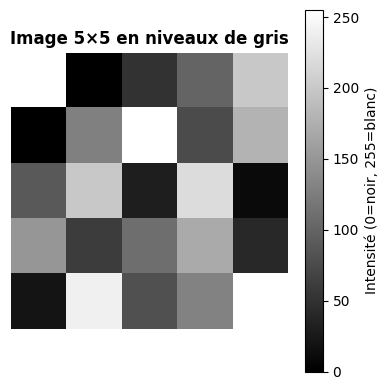

In [8]:
grayscale_image = np.array([
    [255,   0,  50, 100, 200],
    [  0, 128, 255,  75, 180],
    [ 90, 200,  30, 220,  10],
    [150,  60, 110, 170,  40],
    [ 20, 240,  80, 130, 255]
], dtype=np.uint8)

print("Tableau NumPy représentant l'image 5x5 :")
print(grayscale_image)
print(f'\nShape : {grayscale_image.shape}  |  dtype : {grayscale_image.dtype}')
print(f'Valeur minimale : {grayscale_image.min()}  |  Valeur maximale : {grayscale_image.max()}')

plt.figure(figsize=(4, 4))
plt.imshow(grayscale_image, cmap='gray', vmin=0, vmax=255)
plt.colorbar(label='Intensité (0=noir, 255=blanc)')
plt.title('Image 5×5 en niveaux de gris', fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Exercise 6 : Test d'hypothèse — comparaison de deux types de combustible

**Question :** les centrales **Solar** ont-elles une capacité installée (`capacity_mw`) significativement
différente des centrales **Wind** ?

**Hypothèses :**
- **H₀ (nulle)** : la capacité moyenne des centrales Solar est égale à celle des centrales Wind
  (différence moyenne = 0).
- **H₁ (alternative)** : la capacité moyenne diffère entre Solar et Wind.

On utilise un **test t de Student pour échantillons indépendants** (les deux groupes de centrales sont
des populations distinctes, pas des mesures appariées).

Centrales Solar : n=10665, moyenne=17.66 MW, std=41.94 MW
Centrales Wind  : n=5344, moyenne=49.22 MW, std=106.14 MW

Statistique t : -20.9382
p-value       : 0.000000

→ p-value < 0.05 : on rejette H₀. La capacité moyenne diffère significativement entre centrales Solar et Wind.


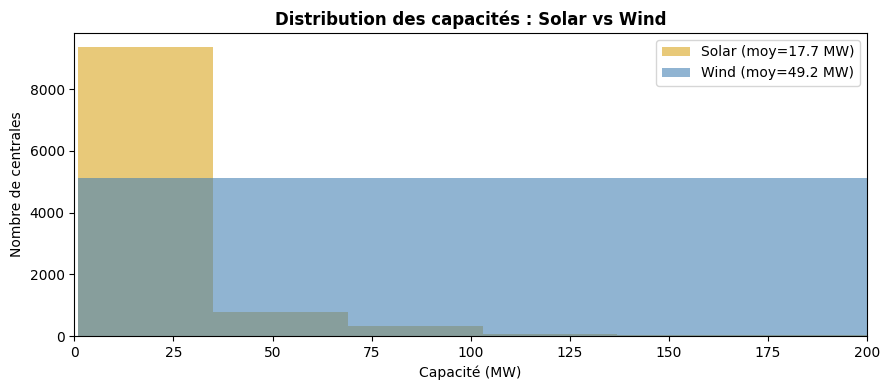

In [9]:
solar_capacity = df_clean.loc[df_clean['primary_fuel'] == 'Solar', 'capacity_mw'].to_numpy()
wind_capacity  = df_clean.loc[df_clean['primary_fuel'] == 'Wind',  'capacity_mw'].to_numpy()

print(f'Centrales Solar : n={len(solar_capacity)}, moyenne={solar_capacity.mean():.2f} MW,'
      f' std={solar_capacity.std(ddof=1):.2f} MW')
print(f'Centrales Wind  : n={len(wind_capacity)}, moyenne={wind_capacity.mean():.2f} MW,'
      f' std={wind_capacity.std(ddof=1):.2f} MW')

# Test t de Student, échantillons indépendants, variances non supposées égales (Welch)
t_stat, p_value = stats.ttest_ind(solar_capacity, wind_capacity, equal_var=False)

print(f'\nStatistique t : {t_stat:.4f}')
print(f'p-value       : {p_value:.6f}')

alpha = 0.05
if p_value < alpha:
    print(f'\n→ p-value < {alpha} : on rejette H₀. La capacité moyenne diffère significativement'
          ' entre centrales Solar et Wind.')
else:
    print(f'\n→ p-value >= {alpha} : on ne peut pas rejeter H₀.')

plt.figure(figsize=(9, 4))
plt.hist(solar_capacity, bins=30, alpha=0.6, color='goldenrod', label=f'Solar (moy={solar_capacity.mean():.1f} MW)')
plt.hist(wind_capacity,  bins=30, alpha=0.6, color='steelblue', label=f'Wind (moy={wind_capacity.mean():.1f} MW)')
plt.xlim(0, 200)
plt.title('Distribution des capacités : Solar vs Wind', fontweight='bold')
plt.xlabel('Capacité (MW)')
plt.ylabel("Nombre de centrales")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Exercise 7 : Comparaison de tableaux — Coal vs Gas (top 10 pays)

Pour les 10 pays ayant le plus de centrales dans le dataset, on compare **élément par élément** la
capacité totale installée au **charbon (Coal)** et au **gaz (Gas)**, afin d'identifier les pays où le
charbon domine encore le gaz en puissance installée.

In [10]:
top_countries = df_clean['country'].value_counts().head(10).index.tolist()

coal_by_country = (df_clean[(df_clean['country'].isin(top_countries)) & (df_clean['primary_fuel'] == 'Coal')]
                    .groupby('country')['capacity_mw'].sum()
                    .reindex(top_countries, fill_value=0))
gas_by_country = (df_clean[(df_clean['country'].isin(top_countries)) & (df_clean['primary_fuel'] == 'Gas')]
                   .groupby('country')['capacity_mw'].sum()
                   .reindex(top_countries, fill_value=0))

array1 = coal_by_country.to_numpy()   # capacité Coal
array2 = gas_by_country.to_numpy()    # capacité Gas

comparison = array1 > array2

print('Pays               :', top_countries)
print('Capacité Coal (MW) :', array1.round(0))
print('Capacité Gas  (MW) :', array2.round(0))
print('\nCoal > Gas (booléen) :', comparison)

coal_dominant_countries = np.array(top_countries)[comparison]
print(f"\nPays où le charbon dépasse le gaz en capacité installée : {list(coal_dominant_countries)}")
print(f'Nombre de pays concernés : {comparison.sum()} sur {len(top_countries)}')

Pays               : ['USA', 'CHN', 'GBR', 'BRA', 'FRA', 'IND', 'DEU', 'CAN', 'ESP', 'RUS']
Capacité Coal (MW) : [249149. 955718.  12296.   2793.   3575. 204919.  47773.   9772.   8783.
  46072.]
Capacité Gas  (MW) : [546436.  59774.  29916.  11286.   5007.  24948.  24430.  19786.  26159.
 106723.]

Coal > Gas (booléen) : [False  True False False False  True  True False False False]

Pays où le charbon dépasse le gaz en capacité installée : [np.str_('CHN'), np.str_('IND'), np.str_('DEU')]
Nombre de pays concernés : 3 sur 10


## 9. Exercise 8 : Série temporelle — évolution du mix énergétique par année de mise en service

On construit une série temporelle du nombre de centrales mises en service chaque année
(`commissioning_year`), pour les 5 principaux combustibles, et on la découpe par décennie afin
d'analyser comment le mix énergétique mondial a évolué dans le temps.

Période couverte : 1896 - 2020


primary_fuel,Hydro,Solar,Gas,Wind,Coal
commissioning_year,,,,,
2016-01-01,45,464,45,169,84
2017-01-01,22,523,48,105,46
2018-01-01,4,480,52,40,14
2019-01-01,1,458,34,63,0
2020-01-01,0,122,6,17,0


1980s : 1052 centrales mises en service | combustible dominant : Hydro (536 centrales)
1990s : 1164 centrales mises en service | combustible dominant : Gas (491 centrales)
2000s : 2877 centrales mises en service | combustible dominant : Gas (915 centrales)
2010s : 6212 centrales mises en service | combustible dominant : Solar (3310 centrales)


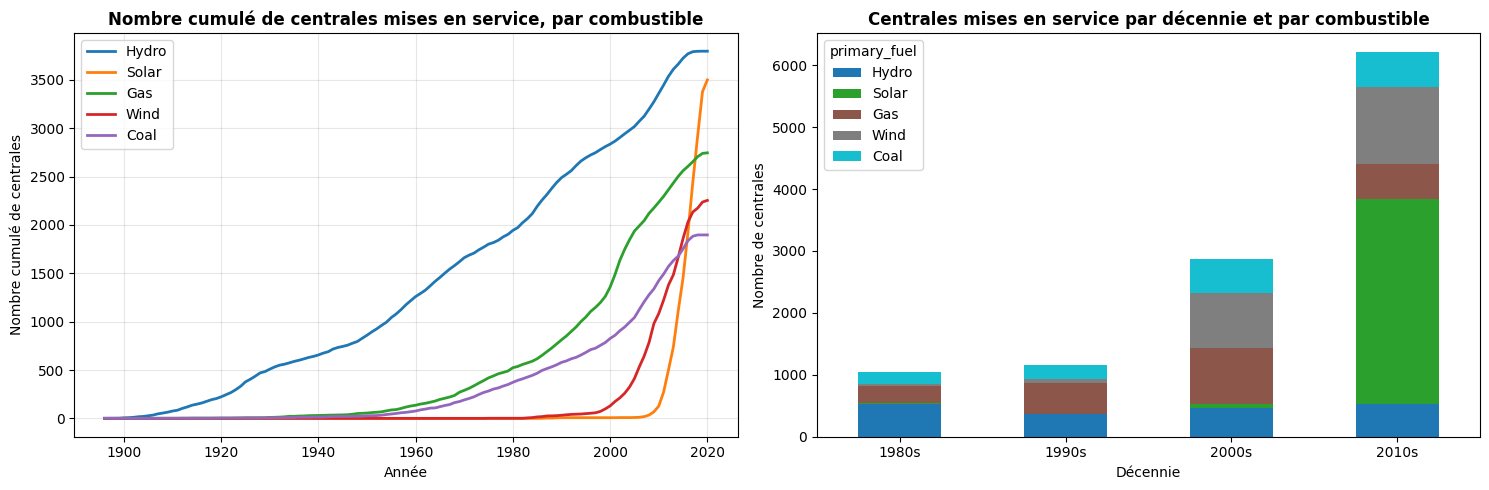


→ Le solaire et l'éolien ne décollent quasiment qu'à partir des années 2010, alors que le gaz et le charbon dominaient les décennies précédentes : le mix énergétique mondial bascule nettement vers le renouvelable sur la période récente.


In [11]:
top5_fuels = df_with_year['primary_fuel'].value_counts().head(5).index.tolist()
df_top5 = df_with_year[df_with_year['primary_fuel'].isin(top5_fuels)]

# Nombre de centrales commissionnées par année et par combustible
yearly_counts = (df_top5.groupby(['commissioning_year', 'primary_fuel']).size()
                  .unstack(fill_value=0)
                  .reindex(columns=top5_fuels, fill_value=0))
yearly_counts.index = pd.to_datetime(yearly_counts.index, format='%Y')

print(f"Période couverte : {yearly_counts.index.min().year} - {yearly_counts.index.max().year}")
display(yearly_counts.tail())

# Découpage par décennie (équivalent du découpage par trimestre de la version originale)
decades = {
    '1980s': yearly_counts['1980':'1989'],
    '1990s': yearly_counts['1990':'1999'],
    '2000s': yearly_counts['2000':'2009'],
    '2010s': yearly_counts['2010':'2019'],
}
for label, block in decades.items():
    totals = block.sum()
    dominant = totals.idxmax()
    print(f'{label} : {int(block.values.sum())} centrales mises en service | '
          f'combustible dominant : {dominant} ({int(totals[dominant])} centrales)')

# Visualisation : évolution cumulée par combustible
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cumulative = yearly_counts.cumsum()
for fuel in top5_fuels:
    axes[0].plot(cumulative.index, cumulative[fuel], linewidth=2, label=fuel)
axes[0].set_title('Nombre cumulé de centrales mises en service, par combustible', fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre cumulé de centrales')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

decade_totals = pd.DataFrame({label: block.sum() for label, block in decades.items()}).T
decade_totals.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10')
axes[1].set_title('Centrales mises en service par décennie et par combustible', fontweight='bold')
axes[1].set_xlabel('Décennie')
axes[1].set_ylabel('Nombre de centrales')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print('\n→ Le solaire et l\'éolien ne décollent quasiment qu\'à partir des années 2010, alors que le'
      ' gaz et le charbon dominaient les décennies précédentes : le mix énergétique mondial bascule'
      ' nettement vers le renouvelable sur la période récente.')

## 10. Exercise 9 : Conversion NumPy ↔ Pandas — capacités par pays

Démonstration de la conversion bidirectionnelle entre tableau NumPy et DataFrame Pandas, appliquée à
la capacité totale installée des 5 pays les plus représentés dans le dataset.

In [12]:
top5_countries = df_clean['country'].value_counts().head(5).index.tolist()
capacity_top5 = (df_clean[df_clean['country'].isin(top5_countries)]
                  .groupby('country')['capacity_mw']
                  .agg(['sum', 'mean', 'count'])
                  .reindex(top5_countries))

print('DataFrame Pandas original (capacité par pays) :')
display(capacity_top5)

# --- Pandas DataFrame → NumPy ---
numpy_from_df = capacity_top5.to_numpy()
print('\nTableau NumPy converti depuis le DataFrame :')
print(numpy_from_df)
print(f'Type : {type(numpy_from_df)}  |  Shape : {numpy_from_df.shape}')

# --- NumPy → Pandas DataFrame ---
df_from_numpy = pd.DataFrame(numpy_from_df, index=top5_countries,
                              columns=['Total MW', 'Moyenne MW', 'Nb centrales'])
print('\nDataFrame Pandas reconstruit depuis le tableau NumPy :')
display(df_from_numpy)
print(f'Type : {type(df_from_numpy)}')

DataFrame Pandas original (capacité par pays) :


,sum,mean,count
country,,,
USA,1.204638e+06,122.509717,9833
CHN,1.415067e+06,334.136335,4235
GBR,9.715528e+04,35.316352,2751
BRA,1.475893e+05,62.537827,2360
FRA,1.106159e+05,51.329897,2155



Tableau NumPy converti depuis le DataFrame :
[[1.20463805e+06 1.22509717e+02 9.83300000e+03]
 [1.41506738e+06 3.34136335e+02 4.23500000e+03]
 [9.71552845e+04 3.53163520e+01 2.75100000e+03]
 [1.47589271e+05 6.25378268e+01 2.36000000e+03]
 [1.10615929e+05 5.13298974e+01 2.15500000e+03]]
Type : <class 'numpy.ndarray'>  |  Shape : (5, 3)

DataFrame Pandas reconstruit depuis le tableau NumPy :


,Total MW,Moyenne MW,Nb centrales
USA,1.204638e+06,122.509717,9833.0
CHN,1.415067e+06,334.136335,4235.0
GBR,9.715528e+04,35.316352,2751.0
BRA,1.475893e+05,62.537827,2360.0
FRA,1.106159e+05,51.329897,2155.0


Type : <class 'pandas.DataFrame'>


## 11. Exercise 10 : Visualisation — capacité mondiale par type de combustible

Synthèse visuelle des résultats de l'Exercice 4/9 : répartition de la capacité installée mondiale par
type de combustible (barres) et poids relatif de chaque combustible (camembert).

,Total MW,Moyenne MW,Nb centrales
primary_fuel,,,
Coal,1.965541e+06,843.579828,2330
Gas,1.493051e+06,373.449375,3998
Hydro,1.053160e+06,147.171551,7156
Nuclear,4.079118e+05,2091.855179,195
Wind,2.630537e+05,49.224126,5344
Oil,2.618787e+05,112.878754,2320
Solar,1.883123e+05,17.657039,10665
Biomass,3.428130e+04,23.972938,1430
Waste,1.474871e+04,13.809657,1068


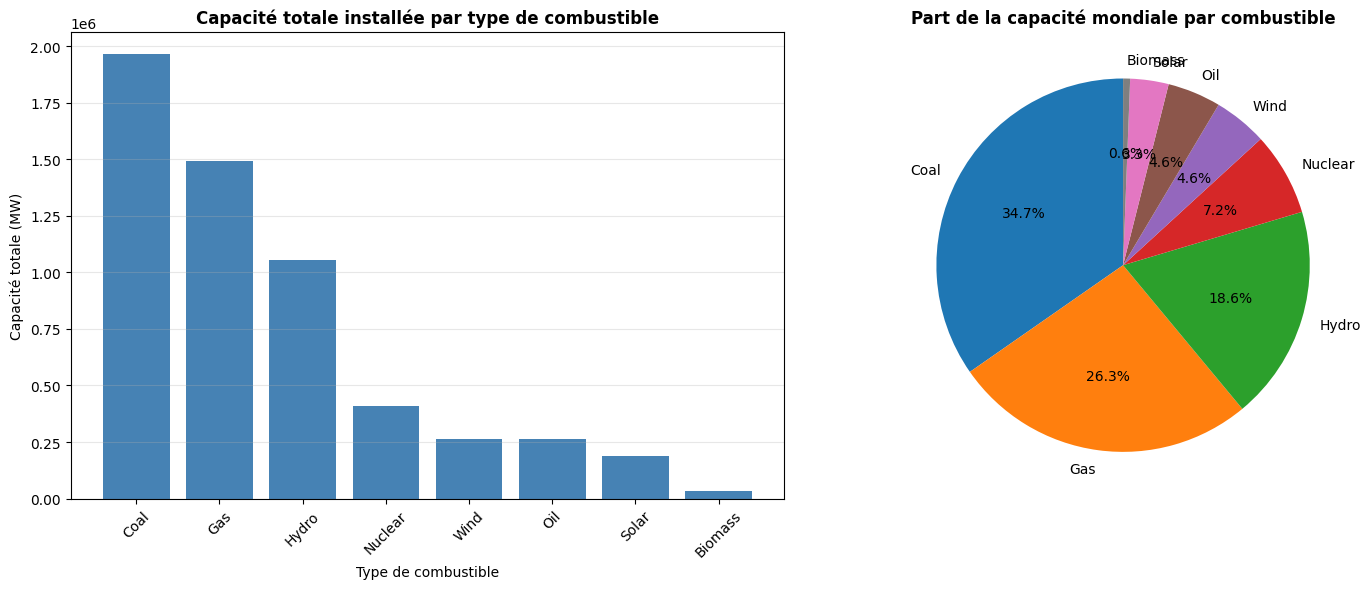

In [13]:
capacity_by_fuel = (df_clean.groupby('primary_fuel')['capacity_mw']
                     .agg(['sum', 'mean', 'count'])
                     .rename(columns={'sum': 'Total MW', 'mean': 'Moyenne MW', 'count': 'Nb centrales'})
                     .sort_values('Total MW', ascending=False))

display(capacity_by_fuel)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top8 = capacity_by_fuel.head(8)
axes[0].bar(top8.index, top8['Total MW'], color='steelblue')
axes[0].set_title('Capacité totale installée par type de combustible', fontweight='bold')
axes[0].set_xlabel('Type de combustible')
axes[0].set_ylabel('Capacité totale (MW)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].pie(top8['Total MW'], labels=top8.index, autopct='%1.1f%%', startangle=90,
            colors=plt.cm.tab10.colors)
axes[1].set_title('Part de la capacité mondiale par combustible', fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Conclusion — synthèse de l'analyse du Global Power Plant Database

**Nettoyage :** sur 34 936 centrales, les colonnes clés (`capacity_mw`, `primary_fuel`, localisation,
`country`, `name`) sont quasi complètes. En revanche `commissioning_year` manque pour environ la moitié
des centrales ; elle a donc été isolée dans un sous-ensemble dédié (`df_with_year`) plutôt que de
réduire tout le dataset.

**Répartition du mix énergétique (Exercices 4, 10) :** le solaire et l'hydraulique dominent en nombre
de centrales, mais l'hydraulique, le charbon et le gaz restent en tête en capacité totale installée
(MW), portés par de grandes infrastructures unitaires.

**Dispersion des capacités (Exercice 2) :** la moyenne de capacité est nettement supérieure à la
médiane, signe d'une distribution très asymétrique — un petit nombre de très grandes centrales tire la
moyenne mondiale vers le haut.

**Indépendance des variables (Exercice 1) :** la matrice de corrélation entre capacité, localisation et
année de mise en service est proche de la matrice identité (déterminant proche de 1) : ces variables
n'apportent pas d'information redondante entre elles.

**Solar vs Wind (Exercice 6) :** le test t de Welch montre une différence statistiquement significative
de capacité moyenne entre centrales solaires et éoliennes — les centrales éoliennes ont en moyenne une
capacité unitaire plus élevée.

**Charbon vs Gaz par pays (Exercice 7) :** parmi les 10 pays les plus représentés, plusieurs conservent
encore une capacité au charbon supérieure à celle au gaz, révélant une transition énergétique inégale
selon les pays.

**Évolution temporelle (Exercice 8) :** le solaire et l'éolien ne prennent une place significative dans
les nouvelles mises en service qu'à partir des années 2010, alors que le charbon et le gaz dominaient
les décennies précédentes — une bascule nette et récente du mix énergétique mondial vers le
renouvelable.

**Limites :** l'absence de `commissioning_year` pour ~50% des centrales peut biaiser l'analyse
temporelle si les données manquantes ne sont pas réparties uniformément entre pays ou combustibles ;
les conclusions sur l'évolution du mix doivent donc être lues comme indicatives plutôt qu'exhaustives.